# Thermal-image frequency analysis

This notebook extracts the production frequency-analysis workflow from `Thermal_images_view.ipynb`. It is independent of the interactive `Flight` selector: the eight flights and their paired thermal rasters and shape files are listed explicitly below.

The legacy PSD calculation and plotting code is intentionally kept as close to the original as possible. Known issues are documented where they occur so they can be addressed in a later refactor.

In [4]:
import sys
from pathlib import Path

import holoviews as hv
import numpy as np
import pandas as pd
import panel as pn
import xarray as xr
from IPython.display import display
from holoviews import opts
from tqdm.auto import tqdm

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from get_1d_psd import get_1d_psd
from thermal_image_helpers import (
    clip_zones,
    load_shp,
    load_thermal,
    tumbling_filter,
)

pn.extension()
hv.extension("bokeh")

In [5]:
# Plot display mode: use "inline" or "new_tab".
PLOT_MODE = "inline"

try:
    stop_plot_servers()
except NameError:
    pass

_plot_servers = []


def show_plot(plot, title="Thermal image frequency analysis"):
    """Display a plot according to the current PLOT_MODE."""
    if PLOT_MODE == "inline":
        return plot
    if PLOT_MODE == "new_tab":
        server = pn.panel(plot).show(title=title, threaded=True)
        _plot_servers.append(server)
        return None
    raise ValueError(
        f"Unsupported PLOT_MODE {PLOT_MODE!r}; expected 'inline' or 'new_tab'."
    )


def stop_plot_servers():
    """Stop every plot server started by show_plot in this kernel session."""
    while _plot_servers:
        _plot_servers.pop().stop()

## Static flight manifest

In [6]:
FLIGHTS = [
    {
        "field": "Waarmaarde",
        "date": "20220428",
        "sinus_tif": "./data/local/Waarmaarde/20220428/sinus/thermal/ortho/220814_Waarm_Thermal_Georef.tif",
        "blok_tif": "./data/local/Waarmaarde/20220428/blok/thermal/ortho/220814_Waarm_Thermal_Georef.tif",
        "sinus_shp": "./data/raw/shape_files/corrected_WaarmaardeOost_sinus_maaien_2021_09.shp",
        "blok_shp": "./data/raw/shape_files/WaarmaardeOost_blok_maaien_2021_09.shp",
    },
    {
        "field": "Muziekbos",
        "date": "20220617",
        "sinus_tif": "./data/local/Muziekbos/20220617/sinus/thermal/ortho/220617_Muziek_fl2_Thermal.tif",
        "blok_tif": "./data/local/Muziekbos/20220617/blok/thermal/ortho/220617_Muziek_fl1_Thermal.tif",
        "sinus_shp": "./data/raw/shape_files/corrected_Muziekbos_sinus_maaien_2021_09.shp",
        "blok_shp": "./data/raw/shape_files/corrected_Muziekbos_blok_maaien_2021_09.shp",
    },
    {
        "field": "Palingbeek",
        "date": "20220617",
        "sinus_tif": "./data/local/Palingbeek/20220617/sinus/thermal/ortho/20220617_Paling_Thermal.tif",
        "blok_tif": "./data/local/Palingbeek/20220617/blok/thermal/ortho/20220617_Paling_Thermal.tif",
        "sinus_shp": "./data/raw/shape_files/corrected_Palingbeek_sinus_maaien_2021_09.shp",
        "blok_shp": "./data/raw/shape_files/Palingbeek_blok_maaien_2021_09.shp",
    },
    {
        "field": "Muziekbos",
        "date": "20220705",
        "sinus_tif": "./data/local/Muziekbos/20220705/sinus/thermal/ortho/220705_Muziek_Sin_Thermal.tif",
        "blok_tif": "./data/local/Muziekbos/20220705/blok/thermal/ortho/220705_Muziek_Block_Thermal.tif",
        "sinus_shp": "./data/raw/shape_files/corrected_Muziekbos_sinus_maaien_2022_06.shp",
        "blok_shp": "./data/raw/shape_files/corrected_Muziekbos_blok_maaien_2022_06.shp",
    },
    {
        "field": "Waarmaarde",
        "date": "20220705",
        "sinus_tif": "./data/local/Waarmaarde/20220705/sinus/thermal/ortho/220507_Waarm_Thermal.tif",
        "blok_tif": "./data/local/Waarmaarde/20220705/blok/thermal/ortho/220507_Waarm_Thermal.tif",
        "sinus_shp": "./data/raw/shape_files/corrected_WaarmaardeOost_sinus_maaien_2022_06.shp",
        "blok_shp": "./data/raw/shape_files/corrected_WaarmaardeOost_blok_maaien_2022_06.shp",
    },
    {
        "field": "Muziekbos",
        "date": "20220831",
        "sinus_tif": "./data/local/Muziekbos/20220831/sinus/thermal/ortho/220831_Muziek_Thermal.tif",
        "blok_tif": "./data/local/Muziekbos/20220831/blok/thermal/ortho/220831_Muziek_Thermal.tif",
        "sinus_shp": "./data/raw/shape_files/corrected_Muziekbos_sinus_maaien_2022_06.shp",
        "blok_shp": "./data/raw/shape_files/corrected_Muziekbos_blok_maaien_2022_06.shp",
    },
    {
        "field": "Waarmaarde",
        "date": "20220831",
        "sinus_tif": "./data/local/Waarmaarde/20220831/sinus/thermal/ortho/220831_Waarm_Thermal.tif",
        "blok_tif": "./data/local/Waarmaarde/20220831/blok/thermal/ortho/220831_Waarm_Thermal.tif",
        "sinus_shp": "./data/raw/shape_files/corrected_WaarmaardeOost_sinus_maaien_2022_06.shp",
        "blok_shp": "./data/raw/shape_files/corrected_WaarmaardeOost_blok_maaien_2022_06.shp",
    },
    {
        "field": "Palingbeek",
        "date": "20220901",
        "sinus_tif": "./data/local/Palingbeek/20220901/sinus/thermal/ortho/220901_Paling_Thermal.tif",
        "blok_tif": "./data/local/Palingbeek/20220901/blok/thermal/ortho/220901_Paling_Thermal.tif",
        "sinus_shp": "./data/raw/shape_files/corrected_Palingbeek_sinus_maaien_2022_06.shp",
        "blok_shp": "./data/raw/shape_files/corrected_Palingbeek_blok_maaien_2022_06.shp",
    },
]

pd.DataFrame(FLIGHTS)

,field,date,sinus_tif,blok_tif,sinus_shp,blok_shp
0,Waarmaarde,20220428,./data/local/Waarmaarde/20220428/sinus/thermal...,./data/local/Waarmaarde/20220428/blok/thermal/...,./data/raw/shape_files/corrected_WaarmaardeOos...,./data/raw/shape_files/WaarmaardeOost_blok_maa...
1,Muziekbos,20220617,./data/local/Muziekbos/20220617/sinus/thermal/...,./data/local/Muziekbos/20220617/blok/thermal/o...,./data/raw/shape_files/corrected_Muziekbos_sin...,./data/raw/shape_files/corrected_Muziekbos_blo...
2,Palingbeek,20220617,./data/local/Palingbeek/20220617/sinus/thermal...,./data/local/Palingbeek/20220617/blok/thermal/...,./data/raw/shape_files/corrected_Palingbeek_si...,./data/raw/shape_files/Palingbeek_blok_maaien_...
3,Muziekbos,20220705,./data/local/Muziekbos/20220705/sinus/thermal/...,./data/local/Muziekbos/20220705/blok/thermal/o...,./data/raw/shape_files/corrected_Muziekbos_sin...,./data/raw/shape_files/corrected_Muziekbos_blo...
4,Waarmaarde,20220705,./data/local/Waarmaarde/20220705/sinus/thermal...,./data/local/Waarmaarde/20220705/blok/thermal/...,./data/raw/shape_files/corrected_WaarmaardeOos...,./data/raw/shape_files/corrected_WaarmaardeOos...
5,Muziekbos,20220831,./data/local/Muziekbos/20220831/sinus/thermal/...,./data/local/Muziekbos/20220831/blok/thermal/o...,./data/raw/shape_files/corrected_Muziekbos_sin...,./data/raw/shape_files/corrected_Muziekbos_blo...
6,Waarmaarde,20220831,./data/local/Waarmaarde/20220831/sinus/thermal...,./data/local/Waarmaarde/20220831/blok/thermal/...,./data/raw/shape_files/corrected_WaarmaardeOos...,./data/raw/shape_files/corrected_WaarmaardeOos...
7,Palingbeek,20220901,./data/local/Palingbeek/20220901/sinus/thermal...,./data/local/Palingbeek/20220901/blok/thermal/...,./data/raw/shape_files/corrected_Palingbeek_si...,./data/raw/shape_files/corrected_Palingbeek_bl...


In [8]:
# Get size of each flight
for flight_info in tqdm(FLIGHTS):
    field = flight_info["field"]
    thermal_date = flight_info["date"]

    sinus_shp = load_shp(project_root / flight_info["sinus_shp"])
    blok_shp = load_shp(project_root / flight_info["blok_shp"])

    sinus_thermal = load_thermal(
        project_root / flight_info["sinus_tif"],
        sinus_shp.geometry[0].union(sinus_shp.geometry[1]),
    )
    blok_thermal = load_thermal(
        project_root / flight_info["blok_tif"],
        blok_shp.geometry[0].union(blok_shp.geometry[1]),
    )

    s_total = sinus_shp.geometry[0].area + sinus_shp.geometry[1].area
    b_total = blok_shp.geometry[0].area + blok_shp.geometry[1].area

    print(f"Field: {field}, Date: {thermal_date}")
    print(f"Blok total area: {b_total:.2f}")
    print(f"Sinus total area: {s_total:.2f}")
    print()

  0%|          | 0/8 [00:00<?, ?it/s]

Field: Waarmaarde, Date: 20220428
Blok total area: 2660.08
Sinus total area: 2611.02

Field: Muziekbos, Date: 20220617
Blok total area: 2119.51
Sinus total area: 2100.83

Field: Palingbeek, Date: 20220617
Blok total area: 11967.31
Sinus total area: 10972.34

Field: Muziekbos, Date: 20220705
Blok total area: 2139.05
Sinus total area: 2103.50

Field: Waarmaarde, Date: 20220705
Blok total area: 2665.37
Sinus total area: 2615.93

Field: Muziekbos, Date: 20220831
Blok total area: 2139.05
Sinus total area: 2103.50

Field: Waarmaarde, Date: 20220831
Blok total area: 2665.37
Sinus total area: 2615.93

Field: Palingbeek, Date: 20220901
Blok total area: 11970.55
Sinus total area: 10967.67



## Loading data

## Frequency-power heatmaps

  0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_4034041/2540826556.py:82: RuntimeWarning: divide by zero encountered in scalar divide
  label=f"Freq: {freqs[f]:.1f}-{freqs[f+1]:.1f} cycles/m \n Wavelength {1/freqs[f]:.2f}-{1/freqs[f+1]:.2f} m",


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

/tmp/ipykernel_4034041/2540826556.py:82: RuntimeWarning: divide by zero encountered in scalar divide
  label=f"Freq: {freqs[f]:.1f}-{freqs[f+1]:.1f} cycles/m \n Wavelength {1/freqs[f]:.2f}-{1/freqs[f+1]:.2f} m",


:Layout
   .Image.Freq_colon_0_full_stop_0_hyphen_minus_2_full_stop_5_cycles_over_m_Wavelength_inf_hyphen_minus_0_full_stop_40_m            :Image   [sinus_x,sinus_y]   (0)
   .Image.Freq_colon_2_full_stop_5_hyphen_minus_5_full_stop_0_cycles_over_m_Wavelength_0_full_stop_40_hyphen_minus_0_full_stop_20_m :Image   [sinus_x,sinus_y]   (1)
   .Image.Freq_colon_5_full_stop_0_hyphen_minus_7_full_stop_6_cycles_over_m_Wavelength_0_full_stop_20_hyphen_minus_0_full_stop_13_m :Image   [sinus_x,sinus_y]   (2)
   .Image.I                                                                                                                         :Image   [blok_x,blok_y]   (0)
   .Image.II                                                                                                                        :Image   [blok_x,blok_y]   (1)
   .Image.III                                                                                                                       :Image   [blok_x,blok_y]   (2)
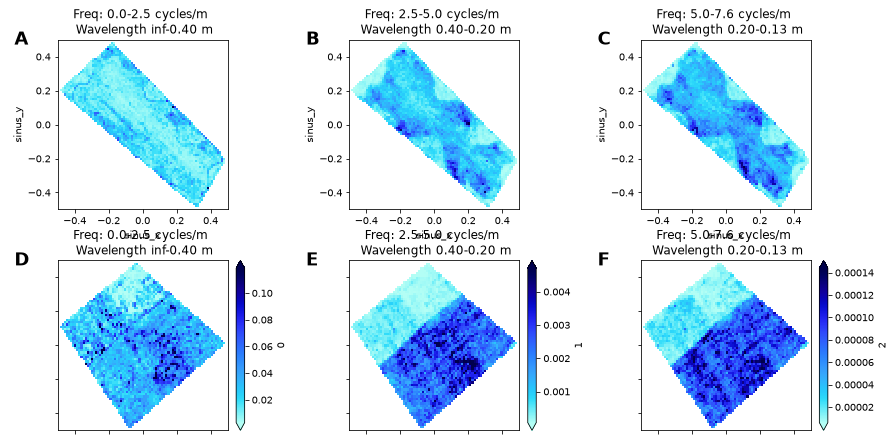

In [9]:
# Automatic frequency ranges

# Options: Waarmaarde_20220428, Muziekbos_20220617, Palingbeek_20220617,
# Muziekbos_20220705, Waarmaarde_20220705, Muziekbos_20220831,
# Waarmaarde_20220831, Palingbeek_20220901
selected_flight = "Palingbeek_20220901"

window_size_m = 2
transform_type = "DCT"
bin_size = 10

clim_min_list = None
clim_max_list = None
#clim_min_list = [0, 0, 0]
#clim_max_list = [0.14, 0.006, 0.00025]

frequency_heatmap_layouts = {}

flight_options = {
    f"{flight_info['field']}_{flight_info['date']}": flight_info
    for flight_info in FLIGHTS
}
if selected_flight not in flight_options:
    raise ValueError(
        f"Unknown flight {selected_flight!r}. "
        f"Choose one of: {', '.join(flight_options)}"
    )

for flight_info in tqdm([flight_options[selected_flight]]):
    field = flight_info["field"]
    thermal_date = flight_info["date"]

    sinus_shp = load_shp(project_root / flight_info["sinus_shp"])
    blok_shp = load_shp(project_root / flight_info["blok_shp"])

    sinus_thermal = load_thermal(
        project_root / flight_info["sinus_tif"],
        sinus_shp.geometry[0].union(sinus_shp.geometry[1]),
    )
    blok_thermal = load_thermal(
        project_root / flight_info["blok_tif"],
        blok_shp.geometry[0].union(blok_shp.geometry[1]),
    )

    site_plots = []
    for site_name, thermal in [
        ("sinus", sinus_thermal),
        ("blok", blok_thermal),
    ]:
        gsd = (thermal.x[1] - thermal.x[0]).to_numpy()
        window_samples = int(np.round(window_size_m / gsd))
        real_window_size_m = window_samples * gsd

        res = tumbling_filter(
            thermal,
            window_samples,
            lambda x: get_1d_psd(
                x - x.mean(), transform_type=transform_type, bin_size=bin_size
            ),
        )
        powers = np.array([[c[0] for c in row] for row in res])
        freqs = res[0][0][1] / real_window_size_m
        imgs = []
        save_paths = []
        #for f in range(powers.shape[-1]):
        if clim_min_list is None or clim_max_list is None:
            clim_min_list = [None] * powers.shape[-1]
            clim_max_list = [None] * powers.shape[-1]
        for f, clim_min_fixed, clim_max_fixed in zip(range(powers.shape[-1]), clim_min_list, clim_max_list):
            clim_min = np.nanpercentile(powers[..., f], 1) if clim_min_fixed is None else clim_min_fixed
            clim_max = np.nanpercentile(powers[..., f], 99) if clim_max_fixed is None else clim_max_fixed
            img = (
                    hv.Image(
                        powers[..., f],
                        kdims=[site_name + "_x", site_name + "_y"],
                        vdims=[str(f)],
                        #label=(
                        #    f"{site_name}: "
                        #    f"[{freqs[f]:.1f}-"
                        #    f"{freqs[f + 1]:.1f}[ cycles/m"
                        #),
                        label=f"Freq: {freqs[f]:.1f}-{freqs[f+1]:.1f} cycles/m \n Wavelength {1/freqs[f]:.2f}-{1/freqs[f+1]:.2f} m",
                    ).opts(
                        clim=(
                            clim_min,
                            clim_max,
                        ),
                        xaxis="bare",
                        yaxis="bare",
                        colorbar=True,
                    )
                )
            # save_dir = "./output_figs/freq_analysis/temp_heterogeneity"
            save_dir = "./output_figs/freq_analysis/temp_heterogeneity_v2"

            save_path = "%s/%s_%s_%d.png" % (save_dir, field, site_name, f)
            save_paths.append(save_path)
            imgs.append(img)
        layout = hv.Layout(imgs)
        site_plots.append(layout)

        hv.extension("matplotlib")
        for img, save_path in zip(imgs, save_paths):
            hv.save(img, save_path)
        #)

    flight_key = f"{field}_{thermal_date}"
    flight_layout = (site_plots[0] + site_plots[1]).cols(len(site_plots[0]))
    frequency_heatmap_layouts[flight_key] = flight_layout

    displayed_plot = show_plot(
        flight_layout,
        title=f"Frequency-power heatmaps: {field} {thermal_date}",
    )
    if displayed_plot is not None:
        display(displayed_plot)

  0%|          | 0/1 [00:00<?, ?it/s]

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:Layout
   .Image.Freq_colon_less_than_1_full_stop_25_cycles_over_m_Wavelength_colon_greater_than_0_full_stop_80_m                                  :Image   [sinus_x,sinus_y]   (0)
   .Image.Freq_colon_1_full_stop_25_hyphen_minus_2_full_stop_50_cycles_over_m_Wavelength_colon_0_full_stop_40_hyphen_minus_0_full_stop_80_m :Image   [sinus_x,sinus_y]   (1)
   .Image.Freq_colon_greater_than_2_full_stop_50_cycles_over_m_Wavelength_colon_less_than_0_full_stop_40_m                                  :Image   [sinus_x,sinus_y]   (2)
   .Image.I                                                                                                                                 :Image   [blok_x,blok_y]   (0)
   .Image.II                                                                                                                                :Image   [blok_x,blok_y]   (1)
   .Image.III                                                                                                                               :Image   [blok_x,blok_y]   (2)
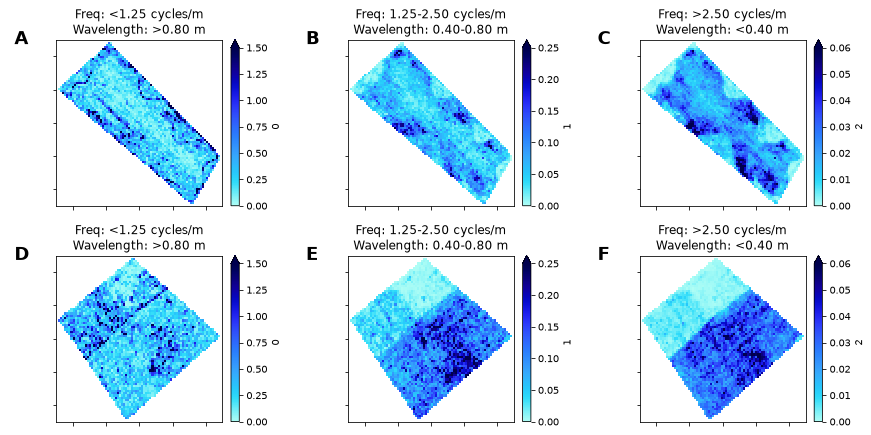

In [18]:
# Same as above, but with fixed frequency ranges

# Options: Waarmaarde_20220428, Muziekbos_20220617, Palingbeek_20220617,
# Muziekbos_20220705, Waarmaarde_20220705, Muziekbos_20220831,
# Waarmaarde_20220831, Palingbeek_20220901
selected_flight = "Palingbeek_20220901"

window_size_m = 2
transform_type = "DCT"

# New: hard-coded frequency ranges for the three frequency bands of interest
freq_ranges = [(0, 1.25), (1.25, 2.5), (2.5, np.inf)] # Excludes fmin, includes fmax. (so 0 is excluded in first one)

#clim_min_list = None
#clim_max_list = None
clim_min_list = [0, 0, 0]
clim_max_list = [1.5, 0.25, 0.06]

frequency_heatmap_layouts = {}

flight_options = {
    f"{flight_info['field']}_{flight_info['date']}": flight_info
    for flight_info in FLIGHTS
}
if selected_flight not in flight_options:
    raise ValueError(
        f"Unknown flight {selected_flight!r}. "
        f"Choose one of: {', '.join(flight_options)}"
    )

for flight_info in tqdm([flight_options[selected_flight]]):
    field = flight_info["field"]
    thermal_date = flight_info["date"]

    sinus_shp = load_shp(project_root / flight_info["sinus_shp"])
    blok_shp = load_shp(project_root / flight_info["blok_shp"])

    sinus_thermal = load_thermal(
        project_root / flight_info["sinus_tif"],
        sinus_shp.geometry[0].union(sinus_shp.geometry[1]),
    )
    blok_thermal = load_thermal(
        project_root / flight_info["blok_tif"],
        blok_shp.geometry[0].union(blok_shp.geometry[1]),
    )

    site_plots = []
    for site_name, thermal in [
        ("sinus", sinus_thermal),
        ("blok", blok_thermal),
    ]:
        gsd = (thermal.x[1] - thermal.x[0]).to_numpy()
        window_samples = int(np.round(window_size_m / gsd))
        real_window_size_m = window_samples * gsd

        res = tumbling_filter(
            thermal,
            window_samples,
            lambda x: get_1d_psd(
                x - x.mean(), transform_type=transform_type, bin_size=1 # bin_size 1, aggregate later
            ),
        )
        powers = np.array([[c[0] for c in row] for row in res])
        freqs = res[0][0][1] / real_window_size_m

        # New: compute band powers for the specified frequency ranges
        band_powers = []
        for fmin, fmax in freq_ranges:
            mask = (freqs[:-1] > fmin) & (freqs[1:] <= fmax)
            band = powers[..., mask]
            band_powers.append(np.where(np.isnan(band).all(axis=-1), np.nan, np.nansum(band, axis=-1),))
            # If all is NaN, append Nan instead 
        band_powers = np.stack(band_powers, axis=-1)

        imgs = []
        save_paths = []
        #for f in range(powers.shape[-1]):
        if clim_min_list is None or clim_max_list is None:
            clim_min_list = [None] * band_powers.shape[-1]
            clim_max_list = [None] * band_powers.shape[-1]

        for i, ((fmin, fmax), clim_min_fixed, clim_max_fixed) in enumerate(zip(freq_ranges, clim_min_list, clim_max_list)):
            clim_min = np.nanpercentile(band_powers[..., i], 1) if clim_min_fixed is None else clim_min_fixed
            clim_max = np.nanpercentile(band_powers[..., i], 99) if clim_max_fixed is None else clim_max_fixed
            
            img = (
                    hv.Image(
                        band_powers[..., i],
                        kdims=[site_name + "_x", site_name + "_y"],
                        vdims=[str(i)],
                        #label=(
                        #    f"{site_name}: "
                        #    f"[{freqs[f]:.1f}-"
                        #    f"{freqs[f + 1]:.1f}[ cycles/m"
                        #),
                        label=(
                            f"Freq: <{fmax:.2f} cycles/m\nWavelength: >{1 / fmax:.2f} m" if i == 0 else
                            f"Freq: >{fmin:.2f} cycles/m\nWavelength: <{1 / fmin:.2f} m" if i == len(freq_ranges) - 1 else
                            f"Freq: {fmin:.2f}-{fmax:.2f} cycles/m\nWavelength: {1 / fmax:.2f}-{1 / fmin:.2f} m"
                        ),
                    ).opts(
                        clim=(
                            clim_min,
                            clim_max,
                        ),
                        xaxis="bare",
                        yaxis="bare",
                        colorbar=True,
                    )
                )
            # save_dir = "./output_figs/freq_analysis/temp_heterogeneity"
            save_dir = "./output_figs/freq_analysis/temp_heterogeneity_fixed_v2"

            save_path = "%s/%s_%s_%d.png" % (save_dir, field, site_name, i)
            save_paths.append(save_path)
            imgs.append(img)
        layout = hv.Layout(imgs)
        site_plots.append(layout)

        hv.extension("matplotlib")
        for img, save_path in zip(imgs, save_paths):
            hv.save(img, save_path)
        #)

    flight_key = f"{field}_{thermal_date}"
    flight_layout = (site_plots[0] + site_plots[1]).cols(len(site_plots[0]))
    frequency_heatmap_layouts[flight_key] = flight_layout

    displayed_plot = show_plot(
        flight_layout,
        title=f"Frequency-power heatmaps: {field} {thermal_date}",
    )
    if displayed_plot is not None:
        display(displayed_plot)

In [7]:
! tar -czf output_figs.tar.gz output_figs

## One-dimensional PSDs for all heatmaps

In [10]:
# Apply 1D PSD for all positions in the grasslands.
def get_windowed_1d_psd(
    site_name,
    shp,
    thermal,
    window_size_m,
    field,
    thermal_date,
    transform_type="DCT",
    average_power_band=True,
    fft_window=True,
):
    total = pd.DataFrame()
    nomow, mow, edge = clip_zones(thermal, shp, edge_size=1)

    for data, part_name in zip([nomow, mow, edge], ["nomow", "mow", "edge"]):
        gsd = (data.x[1] - data.x[0]).to_numpy()
        window_size_samples = int(np.round(window_size_m / gsd))
        real_window_size_m = window_size_samples * gsd

        res = tumbling_filter(
            data,
            window_size_samples,
            lambda x: get_1d_psd(
                x - x.mean(),
                transform_type=transform_type,
                fft_window=fft_window,
                average_power_band=average_power_band,
            ),
        )

        powers = np.array([[c[0] for c in row] for row in res])
        freqs = res[0][0][1] / real_window_size_m
        # Shape: N_windows x N_freqs
        valid_rows, valid_columns = np.nonzero(
            ~np.isnan(powers).all(axis=-1)
        )
        psd_list = powers[valid_rows, valid_columns]
        row_starts = valid_rows * window_size_samples
        column_starts = valid_columns * window_size_samples
        x_coordinates = (
            data.x.values[column_starts]
            + data.x.values[column_starts + window_size_samples - 1]
        ) / 2
        y_coordinates = (
            data.y.values[row_starts]
            + data.y.values[row_starts + window_size_samples - 1]
        ) / 2

        part_data = pd.DataFrame(
            {
                "freq": list(freqs[:-1]) * psd_list.shape[0],
                "average power": psd_list.flatten(),
                "x_coordinate": np.repeat(x_coordinates, psd_list.shape[-1]),
                "y_coordinate": np.repeat(y_coordinates, psd_list.shape[-1]),
            }
        )
        part_data["Part"] = part_name
        part_data["Site"] = site_name
        part_data["Locatie"] = field
        part_data["Datum"] = thermal_date
        total = pd.concat([total, part_data])
    return total

In [11]:
total = pd.DataFrame()
window_size_m = 2
gsd_m = 0.064
transform_type = "DCT"
edge_size = 1
average_power = True
pow_col_name = "average_power band" if average_power else "total_power_band"

for flight_info in tqdm(FLIGHTS):
    field = flight_info["field"]
    thermal_date = flight_info["date"]

    try:
        sinus_shp = load_shp(project_root / flight_info["sinus_shp"])
        blok_shp = load_shp(project_root / flight_info["blok_shp"])
    except Exception:
        print("Shape file not found, skipping flight", field, thermal_date)
        continue

    try:
        sinus_thermal = load_thermal(
            project_root / flight_info["sinus_tif"],
            sinus_shp.geometry[0].union(sinus_shp.geometry[1]),
            gsd_m=gsd_m,
        )
        sinus_thermal.attrs["mow_pattern"] = "sinus"
        blok_thermal = load_thermal(
            project_root / flight_info["blok_tif"],
            blok_shp.geometry[0].union(blok_shp.geometry[1]),
            gsd_m=gsd_m,
        )
        blok_thermal.attrs["mow_pattern"] = "blok"
    except Exception:
        print("Thermal not found, skipping flight", field, thermal_date)
        continue

    for site_name, shp, thermal in [
        ("sinus", sinus_shp, sinus_thermal),
        ("blok", blok_shp, blok_thermal),
    ]:
        flight_psd = get_windowed_1d_psd(
            site_name,
            shp,
            thermal,
            window_size_m,
            field,
            thermal_date,
            transform_type,
            average_power,
        )
        total = pd.concat([total, flight_psd])

total.head()

  0%|          | 0/8 [00:00<?, ?it/s]

,freq,average power,x_coordinate,y_coordinate,Part,Site,Locatie,Datum
0,0.000000,8.547216e-13,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
1,0.252016,4.208638e-01,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
2,0.504032,8.794777e-02,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
3,0.756048,1.899713e-02,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
4,1.008065,1.320190e-02,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428


## Taking a patch subsample per field

In [9]:
# Initial number of patches per field
total[total.freq==0].groupby(["Locatie", "Datum", "Site"])[["average power"]].count()

average power
Locatie    Datum    Site                
Muziekbos  20220617 blok             436
                    sinus            317
           20220705 blok             400
                    sinus            381
           20220831 blok             400
                    sinus            382
Palingbeek 20220617 blok            2686
                    sinus           2332
           20220901 blok            2792
                    sinus           2307
Waarmaarde 20220428 blok             520
                    sinus            496
           20220705 blok             566
                    sinus            481
           20220831 blok             566
                    sinus            479

### Resampling patches per field

In [10]:
n_samples = 300
group_columns = [
    "Part", "Site", "Locatie", "Datum", "x_coordinate", "y_coordinate"
]
flight_site_columns = ["Locatie", "Datum", "Site"]
complete_patches = total[group_columns].drop_duplicates()
sampled_patches = (
    complete_patches
    .sample(frac=1, random_state=42)
    .groupby(flight_site_columns, group_keys=False)
    .head(n_samples)
)
t_sample = total.merge(
    sampled_patches, on=group_columns
)

t_sample.head()

,freq,average power,x_coordinate,y_coordinate,Part,Site,Locatie,Datum
0,0.000000,8.547216e-13,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
1,0.252016,4.208638e-01,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
2,0.504032,8.794777e-02,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
3,0.756048,1.899713e-02,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
4,1.008065,1.320190e-02,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428


In [11]:
t_sample[t_sample.freq==0].groupby(["Locatie", "Datum", "Site"])[["average power"]].count()

average power
Locatie    Datum    Site                
Muziekbos  20220617 blok             300
                    sinus            300
           20220705 blok             300
                    sinus            300
           20220831 blok             300
                    sinus            300
Palingbeek 20220617 blok             300
                    sinus            300
           20220901 blok             300
                    sinus            300
Waarmaarde 20220428 blok             300
                    sinus            300
           20220705 blok             300
                    sinus            300
           20220831 blok             300
                    sinus            300

In [12]:
def plot_psd(df, label, sem=True, logy=True, logx=True, ylim=(None, None), line_width=2, point_size=3, save_fig=None):
    plot = []
    means = df[["freq", "average power"]].groupby("freq").mean()
    # Drop the first frequency, which is 0 cycles/m (DC).
    means.drop(0, axis=0, inplace=True)
    dx = hv.Dimension("freq", label="Spatial frequency", unit="cycles/m")
    dy = hv.Dimension("average power", label="Average power")
    plot.append(
        hv.Points(means, kdims=[dx, dy], label=label).opts(
            logy=logy, logx=logx, ylim=ylim, size=point_size, line_width=line_width,
            xticks=[0.25, 0.5, 1.25, 2.5, 5, 10],
        )
    )
    if sem:
        sem = df[["freq", "average power"]].groupby("freq").sem()["average power"]
        means["err_neg"] = means["average power"] - sem * 1.96 # z-value to get a 95% CI
        means["err_pos"] = means["average power"] + sem * 1.96
        plot.append(
            hv.Area(means, dx, vdims=["err_neg", "err_pos"]).opts(alpha=0.2, line_width=line_width)
        )
    if save_fig is not None:
        hv.save(hv.Overlay(plot), save_fig)
    return hv.Overlay(plot)

## Mow vs no_mow

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
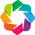

In [21]:
hv.extension("bokeh")

In [22]:
# save_dir = "./output_figs/freq_analysis/mown_vs_unmown"
save_dir = "./output_figs/freq_analysis/mown_vs_unmown_v2"
#legend_position = "top_right"
legend_position = "bottom_left"

In [23]:
LINE_WIDTH = 2
POINT_SIZE = 3
TITLE_SIZE = 14
FONT_SIZE = 15

plots = []
save_paths = []
for (thermal_date, field, site), site_group in t_sample.groupby(
    by=["Datum", "Locatie", "Site"]
):
    site_en = "block" if site == "blok" else site
    formatted_date = f"{thermal_date[-2:]}/{thermal_date[4:6]}/{thermal_date[:4]}"
    # save_path = None
    save_path = "%s/%s_%s_%s.png" % (save_dir, field, site_en, thermal_date)
    save_paths.append(save_path)
    site_plots = []
    for part, group in site_group.groupby(by=["Part"]):  # groupby nomow & mow
        # group with all data from this field
        label = "mown" if part[0] == "mow" else "unmown"
        site_plots.append(
            plot_psd(group, label, logx=True, ylim=(1e-6, 1),sem=True, line_width=LINE_WIDTH, point_size=POINT_SIZE).opts(
                opts.Points(title=f"{field} {site_en} {formatted_date}")
            )
        )

    # Highlighted frequency
    site_plots.append(
        hv.VSpan(1.25, 2.5).opts(
            color="lightblue", alpha=0.4, line_width=0
        )
    )

    plots.append(hv.Overlay(site_plots).opts(
        show_legend=True,
        legend_position=legend_position,
        width=350,
        height=350,
        fontsize={
            "title": f"{TITLE_SIZE}pt",
            "labels": f"{FONT_SIZE}pt",
            "xticks": f"{FONT_SIZE}pt",
            "yticks": f"{FONT_SIZE}pt",
            "legend": f"{FONT_SIZE}pt",
        },
    ))


    #plots.append(hv.Overlay(site_plots).opts(show_legend=True, width=350))

show_plot(
    hv.Layout(plots[6:]).cols(4),
    title="One-dimensional PSDs for all frequency-power heatmaps",
)

:Layout
   .Overlay.I    :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.II   :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.III  :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.IV   :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.V    :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.VI   :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.VII  :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.VIII :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.IX   :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.X    :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]

In [24]:
show_plot(
    hv.Layout(plots[:6]).cols(4),
    title="One-dimensional PSDs for all frequency-power heatmaps",
)

:Layout
   .Overlay.I   :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.II  :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.III :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.IV  :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.V   :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]
   .Overlay.VI  :Overlay
      .Points.Mown   :Points   [freq,average power]
      .Area.I        :Area   [freq]   (err_neg,err_pos)
      .Points.Unmown :Points   [freq,average power]
      .Area.II       :Area   [freq]   (err_neg,err_pos)
      .VSpan.I       :VSpan   [x,y]

In [ ]:
for plot, save_path in zip(plots, save_paths):
    hv.save(plot, save_path)

In [55]:
save_dir = "./output_figs/freq_analysis/block_vs_sinus_v2"
#legend_position = "top_right"
legend_position = "bottom_left"

In [25]:
LINE_WIDTH = 2
POINT_SIZE = 3
TITLE_SIZE = 14
FONT_SIZE = 15

plots = []
save_paths = []
for (datum, locatie), site_group in t_sample.groupby(by=["Datum", "Locatie"]):
    formatted_date = f"{datum[-2:]}/{datum[4:6]}/{datum[:4]}"
    # save_path = None
    save_path = "%s/%s_%s.png" % (save_dir, locatie, datum)
    save_paths.append(save_path)
    site_plots = []
    for site, group in site_group.groupby(by=["Site"]): # groupby block & sinus
        site_en = "block" if site[0] == "blok" else site[0]
        label = "mown" if part[0] == "mow" else "unmown"
        site_plots.append(
            plot_psd(group, site_en, logx=True, ylim=(1e-6, 1), sem=True, line_width=LINE_WIDTH, point_size=POINT_SIZE).opts(
                            opts.Points(title=f"{locatie} {formatted_date}")
                    )
        )

    # Highlighted frequency
    site_plots.append(
        hv.VSpan(1.25, 2.5).opts(
            color="lightblue", alpha=0.4, line_width=0
        )
    )

    plots.append(hv.Overlay(site_plots).opts(
        show_legend=True,
        legend_position=legend_position,
        width=350,
        height=350,
        fontsize={
            "title": f"{TITLE_SIZE}pt",
            "labels": f"{FONT_SIZE}pt",
            "xticks": f"{FONT_SIZE}pt",
            "yticks": f"{FONT_SIZE}pt",
            "legend": f"{FONT_SIZE}pt",
        },
    ))


show_plot(
    hv.Layout(plots[3:]),
    title="Thermal plot (cell 101)",
)

:Layout
   .Overlay.I   :Overlay
      .Points.Block :Points   [freq,average power]
      .Area.I       :Area   [freq]   (err_neg,err_pos)
      .Points.Sinus :Points   [freq,average power]
      .Area.II      :Area   [freq]   (err_neg,err_pos)
      .VSpan.I      :VSpan   [x,y]
   .Overlay.II  :Overlay
      .Points.Block :Points   [freq,average power]
      .Area.I       :Area   [freq]   (err_neg,err_pos)
      .Points.Sinus :Points   [freq,average power]
      .Area.II      :Area   [freq]   (err_neg,err_pos)
      .VSpan.I      :VSpan   [x,y]
   .Overlay.III :Overlay
      .Points.Block :Points   [freq,average power]
      .Area.I       :Area   [freq]   (err_neg,err_pos)
      .Points.Sinus :Points   [freq,average power]
      .Area.II      :Area   [freq]   (err_neg,err_pos)
      .VSpan.I      :VSpan   [x,y]
   .Overlay.IV  :Overlay
      .Points.Block :Points   [freq,average power]
      .Area.I       :Area   [freq]   (err_neg,err_pos)
      .Points.Sinus :Points   [freq,average power]
      .Area.II      :Area   [freq]   (err_neg,err_pos)
      .VSpan.I      :VSpan   [x,y]
   .Overlay.V   :Overlay
      .Points.Block :Points   [freq,average power]
      .Area.I       :Area   [freq]   (err_neg,err_pos)
      .Points.Sinus :Points   [freq,average power]
      .Area.II      :Area   [freq]   (err_neg,err_pos)
      .VSpan.I      :VSpan   [x,y]

In [59]:
show_plot(
    hv.Layout(plots[:3]),
    title="Thermal plot (cell 101)",
)

:Layout
   .Overlay.I   :Overlay
      .Points.Block :Points   [freq,average power]
      .Area.I       :Area   [freq]   (err_neg,err_pos)
      .Points.Sinus :Points   [freq,average power]
      .Area.II      :Area   [freq]   (err_neg,err_pos)
      .VSpan.I      :VSpan   [x,y]
   .Overlay.II  :Overlay
      .Points.Block :Points   [freq,average power]
      .Area.I       :Area   [freq]   (err_neg,err_pos)
      .Points.Sinus :Points   [freq,average power]
      .Area.II      :Area   [freq]   (err_neg,err_pos)
      .VSpan.I      :VSpan   [x,y]
   .Overlay.III :Overlay
      .Points.Block :Points   [freq,average power]
      .Area.I       :Area   [freq]   (err_neg,err_pos)
      .Points.Sinus :Points   [freq,average power]
      .Area.II      :Area   [freq]   (err_neg,err_pos)
      .VSpan.I      :VSpan   [x,y]

In [60]:
for plot, save_path in zip(plots, save_paths):
    hv.save(plot, save_path)

In [61]:
! tar -czf output_figs.tar.gz output_figs

In [18]:
t_sample

,freq,average power,x_coordinate,y_coordinate,Part,Site,Locatie,Datum
0,0.000000,8.547216e-13,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
1,0.252016,4.208638e-01,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
2,0.504032,8.794777e-02,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
3,0.756048,1.899713e-02,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
4,1.008065,1.320190e-02,88325.433425,165224.100946,nomow,sinus,Waarmaarde,20220428
...,...,...,...,...,...,...,...,...
148795,6.552419,2.826055e-05,47355.276745,168974.592554,mow,blok,Palingbeek,20220901
148796,6.804435,3.021104e-05,47355.276745,168974.592554,mow,blok,Palingbeek,20220901
148797,7.056452,1.823070e-05,47355.276745,168974.592554,mow,blok,Palingbeek,20220901
148798,7.308468,1.433431e-05,47355.276745,168974.592554,mow,blok,Palingbeek,20220901


## Create CSV datasets

### Notes for interpreting the exported CSV

- Before calculating the frequency measurements, every thermal heat map is resampled to a ground sampling distance of **0.064 m (6.4 cm)** using average resampling. The values therefore differ slightly from earlier full-resolution results.
- Each row contains the mean DCT-derived power for one non-overlapping, approximately 2 × 2 m patch in one of three **spatial-frequency** bands (units: cycles/m, not Hz): `freq < 1.25` excludes the zero-frequency/DC component, `freq = 1.25-2.5` includes both boundaries, and `freq > 2.5` contains the higher frequencies. Larger `average power` values indicate stronger temperature variation at spatial scales represented by that band.
- A patch is identified by `Locatie`, `Datum`, `Site`, `Part`, `x_coordinate`, and `y_coordinate`. The coordinates are the exact patch centre in Belgian Lambert 72 (`EPSG:31370`), in metres. Compare coordinates within the same location, date, site, and part.
- `Part` is the grassland zone (`nomow`, `mow`, or `edge`), `Site` is the mowing pattern (`sinus` or `blok`), `Locatie` is the field, and `Datum` is the flight date in `YYYYMMDD` format. Each physical patch can appear once per frequency band.

In [ ]:
output_directory = project_root / "./data/derived"
output_directory.mkdir(parents=True, exist_ok=True)

# Summarize the frequency bands below, within, and above 1.25-2.5 cycles/m
low_f = 1.25 
high_f = 2.5 
group_columns = [
    "Part", "Site", "Locatie", "Datum", "x_coordinate", "y_coordinate"
]
frequency_bands = [
    (f"<{low_f}", (t_sample.freq > 0) & (t_sample.freq < low_f)),
    (f"{low_f}-{high_f}", (t_sample.freq >= low_f) & (t_sample.freq <= high_f)),
    (f">{high_f}", t_sample.freq > high_f),
]
frequency_band_summary = pd.concat(
    [
        t_sample[mask].groupby(group_columns).mean().reset_index().assign(freq=label)
        for label, mask in frequency_bands
    ],
    ignore_index=True,
)
summary_output_path = (
    output_directory
    / (
        f"heatmap_frequency_measurements_{window_size_m}x{window_size_m}m_"
        f"{gsd_m}m_gsd_1p25-2p5_cycles_per_m_{n_samples}_samples.xlsx"
    )
)
frequency_band_summary.to_excel(summary_output_path, index=False)

print(f"Wrote {summary_output_path}")
frequency_band_summary

Wrote /home/emield/docs/PhD/projects/thermal-image-analysis/data/derived/heatmap_frequency_measurements_2x2m_0.064m_gsd_1p25-2p5_cycles_per_m_300_samples.xlsx


,Part,Site,Locatie,Datum,x_coordinate,y_coordinate,freq,average power
0,mow,blok,Muziekbos,20220617,99706.068131,162334.395566,<1.25,0.367867
1,mow,blok,Muziekbos,20220617,99708.052131,162334.395566,<1.25,0.239191
2,mow,blok,Muziekbos,20220617,99708.052131,162338.363566,<1.25,0.032216
3,mow,blok,Muziekbos,20220617,99708.052131,162340.347566,<1.25,0.039557
4,mow,blok,Muziekbos,20220617,99710.036131,162332.411566,<1.25,0.251179
...,...,...,...,...,...,...,...,...
14395,nomow,sinus,Waarmaarde,20220831,88359.122692,165214.170369,>2.5,0.000792
14396,nomow,sinus,Waarmaarde,20220831,88363.090692,165208.218369,>2.5,0.001832
14397,nomow,sinus,Waarmaarde,20220831,88363.090692,165210.202369,>2.5,0.002068
14398,nomow,sinus,Waarmaarde,20220831,88365.074692,165208.218369,>2.5,0.002692


In [20]:
# Select only the data for Muziekbos, Datum 20220617 and the sinus field
k = frequency_band_summary[frequency_band_summary['Locatie'] == 'Muziekbos'][frequency_band_summary['Datum'] == '20220705'][frequency_band_summary['Site'] == 'sinus'][frequency_band_summary['freq'] == '1.25-2.5']
hv.Histogram(np.histogram(k['average power']))

/tmp/ipykernel_3068728/1958563718.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  k = frequency_band_summary[frequency_band_summary['Locatie'] == 'Muziekbos'][frequency_band_summary['Datum'] == '20220705'][frequency_band_summary['Site'] == 'sinus'][frequency_band_summary['freq'] == '1.25-2.5']
/tmp/ipykernel_3068728/1958563718.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  k = frequency_band_summary[frequency_band_summary['Locatie'] == 'Muziekbos'][frequency_band_summary['Datum'] == '20220705'][frequency_band_summary['Site'] == 'sinus'][frequency_band_summary['freq'] == '1.25-2.5']
/tmp/ipykernel_3068728/1958563718.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  k = frequency_band_summary[frequency_band_summary['Locatie'] == 'Muziekbos'][frequency_band_summary['Datum'] == '20220705'][frequency_band_summary['Site'] == 'sinus'][frequency_band_summary['freq'] == '1.25-2.5']


:Histogram   [x]   (Frequency)